<a href="https://colab.research.google.com/github/siddharth2004agrawal/AiProject1/blob/AiModules%2Fmodule-10/Day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/iris_data.csv")

In [ ]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print(df.shape[0])

150


In [ ]:
print(df.columns.tolist())

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [ ]:
print(df.dtypes)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [ ]:
 df.species.value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
stats_df=df.describe()

In [ ]:
stats_df.loc['range']=stats_df.loc['max']-stats_df.loc['min']

In [ ]:
out_fields=['mean','25%','50%','75%','range']

In [ ]:
stats_df=stats_df.loc[out_fields]

In [ ]:
stats_df.rename({'50%':'median'},inplace=True)

In [ ]:
stats_df

,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.054,3.758667,1.198667
25%,5.100000,2.800,1.600000,0.300000
median,5.800000,3.000,4.350000,1.300000
75%,6.400000,3.300,5.100000,1.800000
range,3.600000,2.400,5.900000,2.400000


In [ ]:
df.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [ ]:
df.groupby('species').median()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


In [ ]:
df.groupby('species').agg(['mean','median'])

sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa            5.006    5.0       3.418    3.4        1.464   1.50   
versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
virginica         6.588    6.5       2.974    3.0        5.552   5.55   

           petal_width         
                  mean median  
species                        
setosa           0.244    0.2  
versicolor       1.326    1.3  
virginica        2.026    2.0

In [ ]:
df.groupby('species').agg([np.mean,np.median])

/tmp/ipykernel_759/503815786.py:1: FutureWarning: The provided callable <function mean at 0x7d655b5723e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.groupby('species').agg([np.mean,np.median])
/tmp/ipykernel_759/503815786.py:1: FutureWarning: The provided callable <function median at 0x7d65589ae700> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df.groupby('species').agg([np.mean,np.median])
/tmp/ipykernel_759/503815786.py:1: FutureWarning: The provided callable <function mean at 0x7d655b5723e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.groupby('species').agg([np.mean,np.median])


sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa            5.006    5.0       3.418    3.4        1.464   1.50   
versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
virginica         6.588    6.5       2.974    3.0        5.552   5.55   

           petal_width         
                  mean median  
species                        
setosa           0.244    0.2  
versicolor       1.326    1.3  
virginica        2.026    2.0

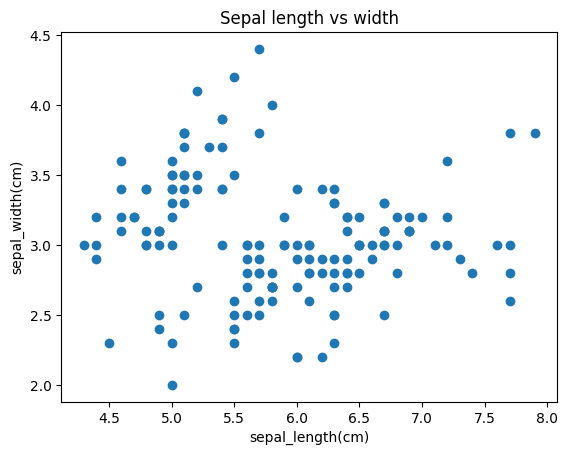

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
ax=plt.axes()
ax.scatter(df.sepal_length,df.sepal_width)
ax.set(xlabel='sepal_length(cm)',ylabel='sepal_width(cm)',title='Sepal length vs width');

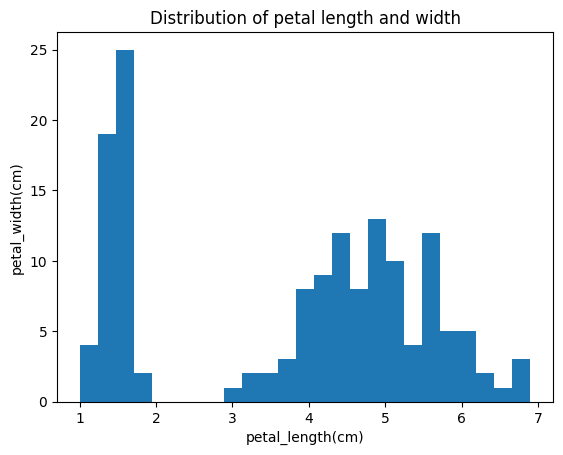

In [ ]:
ax=plt.axes()
ax.hist(df.petal_length,bins=25)
ax.set(xlabel='petal_length(cm)',ylabel='petal_width(cm)',title='Distribution of petal length and width');

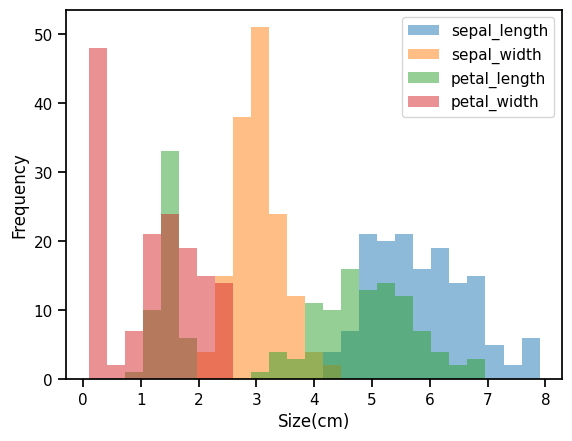

In [ ]:
import seaborn as sns
sns.set_context('notebook')
ax=df.plot.hist(bins=25,alpha=0.5)
ax.set_xlabel('Size(cm)');

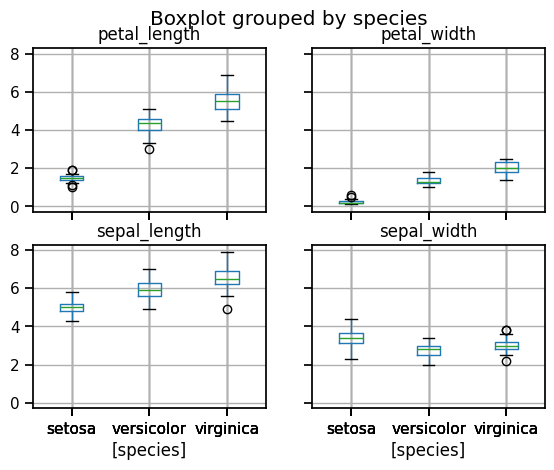

In [ ]:
df.boxplot(by='species');

In [ ]:
plot_data=(df.set_index('species')
.stack()
.to_frame()
.reset_index()
.rename(columns={'level_0':'measurement',0:'size'})
)
plot_data.head()

,species,level_1,size
0,setosa,sepal_length,5.1
1,setosa,sepal_width,3.5
2,setosa,petal_length,1.4
3,setosa,petal_width,0.2
4,setosa,sepal_length,4.9


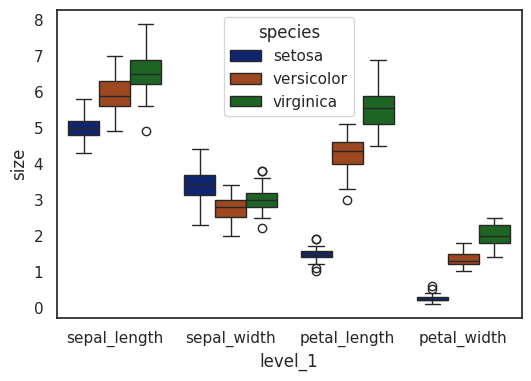

In [ ]:
 sns.set_style('white')
 sns.set_context('notebook')
 sns.set_palette('dark')
 f=plt.figure(figsize=(6,4))
 sns.boxplot(x='level_1',y='size',hue='species',data=plot_data);

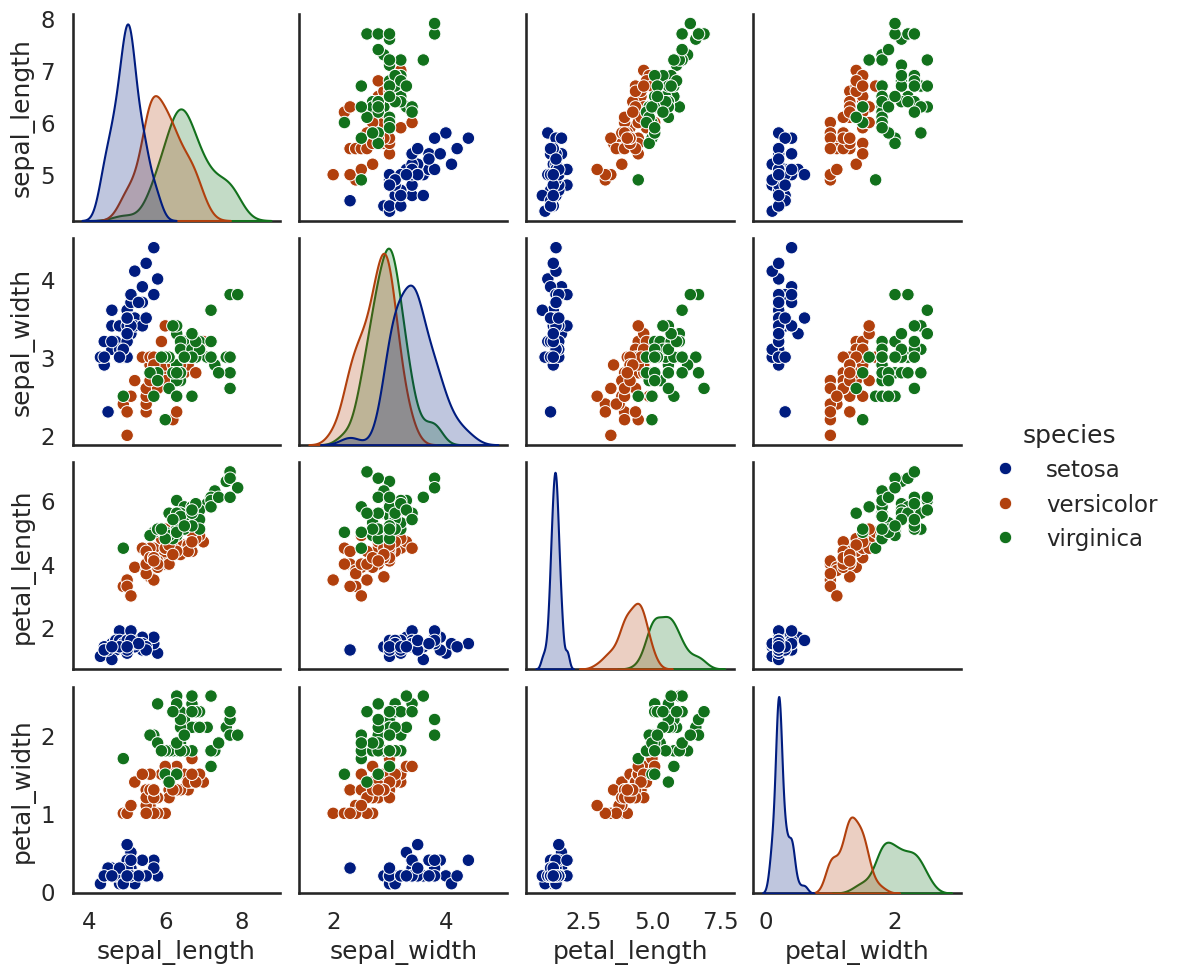

In [ ]:
sns.set_context('talk')
sns.pairplot(df,hue='species');